# 🐄 MMCows — I3-1: Visual Dataset Exploration

**Increment:** I3 — Visual Detection & 3-D Tracking  
**Step:** I3-1 — Explore `visual_data/`, verify structure, understand labels  
**Owner:** Oussema  

---

### What this notebook does
1. Verify the folder structure of `visual data/`
2. Count images per camera and check resolution
3. Read and understand the label format `[cow_id, x, y, w, h]`
4. Visualise sample annotations on real images
5. Inspect projection matrices

> ✅ **Approval gate:** share outputs of this notebook before moving to I3-2


## Cell 1 — Imports & Configuration
Run this first. Adjust `VISUAL_DATA_DIR` if your path is different.

In [14]:
import os
import sys
from pathlib import Path
from collections import defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec

# ── CONFIG ──────────────────────────────────────────────────────────────────
# Path to your extracted visual_data folder (relative to project root)
# If you run this notebook from mmcows_project/, this should work as-is
VISUAL_DATA_DIR = Path("C:\\Users\\DELL\\Desktop\\test\\mmcows\\data\\raw\\visual_data")

# Label set to use: "combined" | "standing" | "lying"
# "combined" = all cows (standing + lying) — this is what we need for detection
LABEL_SET = "combined/0725"

# Official image resolution from the MMCows paper
IMG_W, IMG_H = 4480, 2800

# Where to save output plots
OUTPUT_DIR = Path("C:\\Users\\DELL\\Desktop\\test\\mmcows\\outputs\\results\\i3_1_exploration")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Imports done.")
print(f"   Looking for data at : {VISUAL_DATA_DIR.resolve()}")
print(f"   Saving outputs to   : {OUTPUT_DIR.resolve()}")


✅ Imports done.
   Looking for data at : C:\Users\DELL\Desktop\test\mmcows\data\raw\visual_data
   Saving outputs to   : C:\Users\DELL\Desktop\test\mmcows\outputs\results\i3_1_exploration


## Cell 2 — Verify Folder Structure

Expected layout inside `visual data/` (from the MMCows README):
```
visual data/
├── images/
│   ├── cam_1/   ← 4480×2800 masked isometric images
│   ├── cam_2/
│   ├── cam_3/
│   └── cam_4/
├── labels/
│   ├── combined/    ← all cows (we use this for detection)
│   ├── standing/    ← non-lying cows only
│   └── lying/       ← lying cows only
├── proj_mat/        ← 3D↔2D projection matrices (used in I3-5)
├── behavior_labels/
│   └── individual/
└── visual_location/ ← 3D body locations derived from labels
```


In [10]:
def check(p, label):
    exists = p.exists()
    icon   = "✅" if exists else "❌  MISSING"
    print(f"  {icon}  {label}")
    return exists

print("Checking folder structure under:", VISUAL_DATA_DIR.resolve())
print()

all_ok = True
checks = [
    (VISUAL_DATA_DIR,                          "visual_data/  (root)"),
    (VISUAL_DATA_DIR / "images",               "images/"),
    (VISUAL_DATA_DIR / "images" / "0725" / "cam_1",     "images/0725/cam_1/"),
    (VISUAL_DATA_DIR / "images" / "0725" / "cam_2",     "images/0725/cam_2/"),
    (VISUAL_DATA_DIR / "images" / "0725" / "cam_3",     "images/0725/cam_3/"),
    (VISUAL_DATA_DIR / "images" / "0725" / "cam_4",     "images/0725/cam_4/"),
    (VISUAL_DATA_DIR / "labels",               "labels/"),
    (VISUAL_DATA_DIR / "labels" / "combined",  "labels/combined/"),
    (VISUAL_DATA_DIR / "labels" / "standing",  "labels/standing/"),
    (VISUAL_DATA_DIR / "labels" / "lying",     "labels/lying/"),
    (VISUAL_DATA_DIR / "proj_mat",             "proj_mat/"),
    (VISUAL_DATA_DIR / "behavior_labels",      "behavior_labels/"),
    (VISUAL_DATA_DIR / "visual_location",      "visual_location/"),
]

for path, label in checks:
    ok = check(path, label)
    all_ok = all_ok and ok

print()
if all_ok:
    print("✅ All folders found — structure looks correct.")
else:
    print("⚠️  Some folders are missing.")
    print("   Double-check your extraction and that VISUAL_DATA_DIR is correct.")


Checking folder structure under: C:\Users\DELL\Desktop\test\mmcows\data\raw\visual_data

  ✅  visual_data/  (root)
  ✅  images/
  ✅  images/0725/cam_1/
  ✅  images/0725/cam_2/
  ✅  images/0725/cam_3/
  ✅  images/0725/cam_4/
  ✅  labels/
  ✅  labels/combined/
  ✅  labels/standing/
  ✅  labels/lying/
  ✅  proj_mat/
  ✅  behavior_labels/
  ✅  visual_location/

✅ All folders found — structure looks correct.


## Cell 3 — Peek Inside Each Folder
Let's see the actual contents (first few files in each subfolder).

In [11]:
def peek(folder, n=5, extensions=("*",)):
    """Print the first n files in a folder."""
    folder = Path(folder)
    files  = []
    for ext in extensions:
        files += list(folder.glob(ext))
    files = sorted(files)[:n]
    if not files:
        print(f"    (empty or no matching files)")
    for f in files:
        print(f"    {f.name}")
    return files

for subfolder in ["images/cam_1", "images/cam_2",
                  "labels/combined", "proj_mat",
                  "behavior_labels/individual", "visual_location"]:
    p = VISUAL_DATA_DIR / subfolder
    if not p.exists():
        print(f"\n📁 {subfolder}/  ← NOT FOUND")
        continue

    # For nested dirs, go one level deeper
    subdirs = [d for d in p.iterdir() if d.is_dir()]
    if subdirs:
        print(f"\n📁 {subfolder}/  →  subfolders: {[d.name for d in subdirs[:6]]}")
        # Peek inside first subdir
        print(f"   Files in {subdirs[0].name}/:")
        peek(subdirs[0], n=4)
    else:
        all_files = sorted(p.iterdir())
        print(f"\n📁 {subfolder}/  ({len(all_files)} files)")
        for f in all_files[:5]:
            print(f"    {f.name}")
        if len(all_files) > 5:
            print(f"    ... ({len(all_files) - 5} more)")



📁 images/cam_1/  ← NOT FOUND

📁 images/cam_2/  ← NOT FOUND

📁 labels/combined/  →  subfolders: ['0725']
   Files in 0725/:
    cam_1
    cam_2
    cam_3
    cam_4

📁 proj_mat/  →  subfolders: ['0725']
   Files in 0725/:
    proj_mat_cam1.xml
    proj_mat_cam2.xml
    proj_mat_cam3.xml
    proj_mat_cam4.xml

📁 behavior_labels/individual/  (16 files)
    C01_0725.csv
    C02_0725.csv
    C03_0725.csv
    C04_0725.csv
    C05_0725.csv
    ... (11 more)

📁 visual_location/  →  subfolders: ['C01', 'C02', 'C03', 'C04', 'C05', 'C06']
   Files in C01/:
    C01_0725.csv


## Cell 4 — Count Images & Verify Resolution

The paper says `visual_data.zip` contains ~**20,000 annotated frames** across 4 cameras  
for a single day (7/25), with 15-second intervals.

Expected per camera: ~5,000 images at **4480 × 2800** resolution.


In [12]:
img_root = VISUAL_DATA_DIR / "images" / "0725"
total    = 0

print(f"{'Camera':<12} {'# Images':>10}  {'Resolution':>16}  {'Status'}")
print("─" * 55)

cam_image_counts = {}

for cam_dir in sorted(img_root.iterdir()):
    if not cam_dir.is_dir():
        continue

    images = sorted(cam_dir.glob("*.jpg")) + sorted(cam_dir.glob("*.png"))
    count  = len(images)
    total += count
    cam_image_counts[cam_dir.name] = images  # store for later use

    if images:
        img = cv2.imread(str(images[0]))
        if img is not None:
            h, w, c = img.shape
            res     = f"{w} × {h}"
            status  = "✅" if (h == IMG_H and w == IMG_W) else f"⚠️  expected {IMG_W}×{IMG_H}"
        else:
            res, status = "unreadable", "❌"
    else:
        res, status = "—", "❌ no images"

    print(f"  {cam_dir.name:<10} {count:>10}  {res:>16}  {status}")

print("─" * 55)
print(f"  {'TOTAL':<10} {total:>10}")
print(f"\n  Expected: ~20,000 total  |  ~5,000 per camera")


Camera         # Images        Resolution  Status
───────────────────────────────────────────────────────
  cam_1            5040       4480 × 2800  ✅
  cam_2            5037       4480 × 2800  ✅
  cam_3            5036       4480 × 2800  ✅
  cam_4            5040       4480 × 2800  ✅
───────────────────────────────────────────────────────
  TOTAL           20153

  Expected: ~20,000 total  |  ~5,000 per camera


## Cell 5 — Understand the Label Format

MMCows labels use a **YOLO-style** format:
```
cow_id   x_center   y_center   width   height
```
- All values are **normalised** to [0, 1] relative to the image size (4480 × 2800)
- `cow_id` is a 0-based integer class index (0 = cow #1, 1 = cow #2, etc.)
- Labels are in `labels/combined/` which contains **both standing and lying** cows

We'll read a few label files and decode them into pixel coordinates.


In [15]:
def parse_label_file(label_path):
    """
    Parse a single MMCows .txt label file.

    Returns a list of dicts:
        cow_id (int)       — 0-based cow index
        xc, yc, w, h       — normalised [0,1] bbox centre + size
        x1, y1, x2, y2     — pixel coordinates (top-left, bottom-right)
    """
    annotations = []
    with open(label_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue
            cow_id      = int(parts[0])
            xc, yc, bw, bh = map(float, parts[1:])

            # Convert normalised → pixel
            x1 = int((xc - bw / 2) * IMG_W)
            y1 = int((yc - bh / 2) * IMG_H)
            x2 = int((xc + bw / 2) * IMG_W)
            y2 = int((yc + bh / 2) * IMG_H)

            annotations.append({
                "cow_id": cow_id,
                "xc": xc, "yc": yc, "w": bw, "h": bh,
                "x1": x1, "y1": y1, "x2": x2, "y2": y2,
            })
    return annotations

# ── Find label files ─────────────────────────────────────────
label_root  = VISUAL_DATA_DIR / "labels" / LABEL_SET
label_files = []

# Labels may be flat in combined/ or split into cam_1/, cam_2/ subfolders
subdirs = [d for d in label_root.iterdir() if d.is_dir()]
if subdirs:
    print(f"Labels are organised in subfolders: {[d.name for d in subdirs]}")
    for d in sorted(subdirs):
        label_files += sorted(d.glob("*.txt"))
else:
    print("Labels are flat (no camera subfolders).")
    label_files = sorted(label_root.glob("*.txt"))

print(f"Total label files found : {len(label_files)}")
print()

# ── Print a few raw lines ────────────────────────────────────
sample_lf = label_files[0]
print(f"Sample file: {sample_lf.relative_to(VISUAL_DATA_DIR)}")
print("Raw content:")
with open(sample_lf) as f:
    lines = f.readlines()
for line in lines[:6]:
    print(f"  {line.rstrip()}")

# ── Decode and print human-readable ─────────────────────────
print("\nDecoded (pixel coords for 4480×2800):")
print(f"  {'cow_id':>7} {'xc':>8} {'yc':>8} {'w':>8} {'h':>8}   {'x1':>5} {'y1':>5} {'x2':>5} {'y2':>5}")
print("  " + "─" * 70)
anns = parse_label_file(sample_lf)
for a in anns[:8]:
    print(f"  {a['cow_id']:>7} {a['xc']:>8.4f} {a['yc']:>8.4f} "
          f"{a['w']:>8.4f} {a['h']:>8.4f}   "
          f"{a['x1']:>5} {a['y1']:>5} {a['x2']:>5} {a['y2']:>5}")


Labels are organised in subfolders: ['cam_1', 'cam_2', 'cam_3', 'cam_4']
Total label files found : 20153

Sample file: labels\combined\0725\cam_1\1690271846_02-57-26.txt
Raw content:
  9 0.35691964285714284 0.30660714285714286 0.16919642857142858 0.18321428571428572
  16 0.5859375 0.21821428571428572 0.08973214285714286 0.11
  5 0.68125 0.2675 0.10267857142857142 0.13285714285714287
  12 0.26261160714285714 0.24839285714285714 0.1609375 0.16392857142857142
  1 0.8738839285714286 0.3676785714285714 0.11026785714285714 0.15821428571428572
  2 0.4290178571428571 0.25160714285714286 0.06875 0.06392857142857143

Decoded (pixel coords for 4480×2800):
   cow_id       xc       yc        w        h      x1    y1    x2    y2
  ──────────────────────────────────────────────────────────────────────
        9   0.3569   0.3066   0.1692   0.1832    1220   602  1978  1115
       16   0.5859   0.2182   0.0897   0.1100    2424   457  2826   765
        5   0.6813   0.2675   0.1027   0.1329    2822   56

## Cell 6 — Aggregate Label Statistics
Scan all label files to get per-cow counts, boxes-per-frame distribution, and bbox size stats.

In [16]:
from collections import defaultdict

cow_id_counts   = defaultdict(int)
boxes_per_frame = []
all_xc, all_yc  = [], []
all_bw, all_bh  = [], []
all_anns        = []

for lf in label_files:
    anns = parse_label_file(lf)
    boxes_per_frame.append(len(anns))
    for a in anns:
        cow_id_counts[a["cow_id"]] += 1
        all_xc.append(a["xc"])
        all_yc.append(a["yc"])
        all_bw.append(a["w"])
        all_bh.append(a["h"])
        all_anns.append(a)

print(f"Total annotations       : {len(all_anns):,}")
print(f"Unique cow IDs          : {sorted(cow_id_counts.keys())}")
print(f"Number of cows          : {len(cow_id_counts)}")
print(f"Avg boxes / frame       : {np.mean(boxes_per_frame):.1f}")
print(f"Min / Max boxes / frame : {min(boxes_per_frame)} / {max(boxes_per_frame)}")
print()
print(f"Avg bbox width  (norm)  : {np.mean(all_bw):.4f}  →  ~{np.mean(all_bw)*IMG_W:.0f} px")
print(f"Avg bbox height (norm)  : {np.mean(all_bh):.4f}  →  ~{np.mean(all_bh)*IMG_H:.0f} px")
print(f"Avg centre x    (norm)  : {np.mean(all_xc):.4f}")
print(f"Avg centre y    (norm)  : {np.mean(all_yc):.4f}")


Total annotations       : 213,705
Unique cow IDs          : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
Number of cows          : 16
Avg boxes / frame       : 10.6
Min / Max boxes / frame : 0 / 16

Avg bbox width  (norm)  : 0.1056  →  ~473 px
Avg bbox height (norm)  : 0.1101  →  ~308 px
Avg centre x    (norm)  : 0.5058
Avg centre y    (norm)  : 0.2155


## Cell 7 — Statistics Plots
Visualise per-cow annotation counts, boxes-per-frame distribution, and bbox size heatmap.

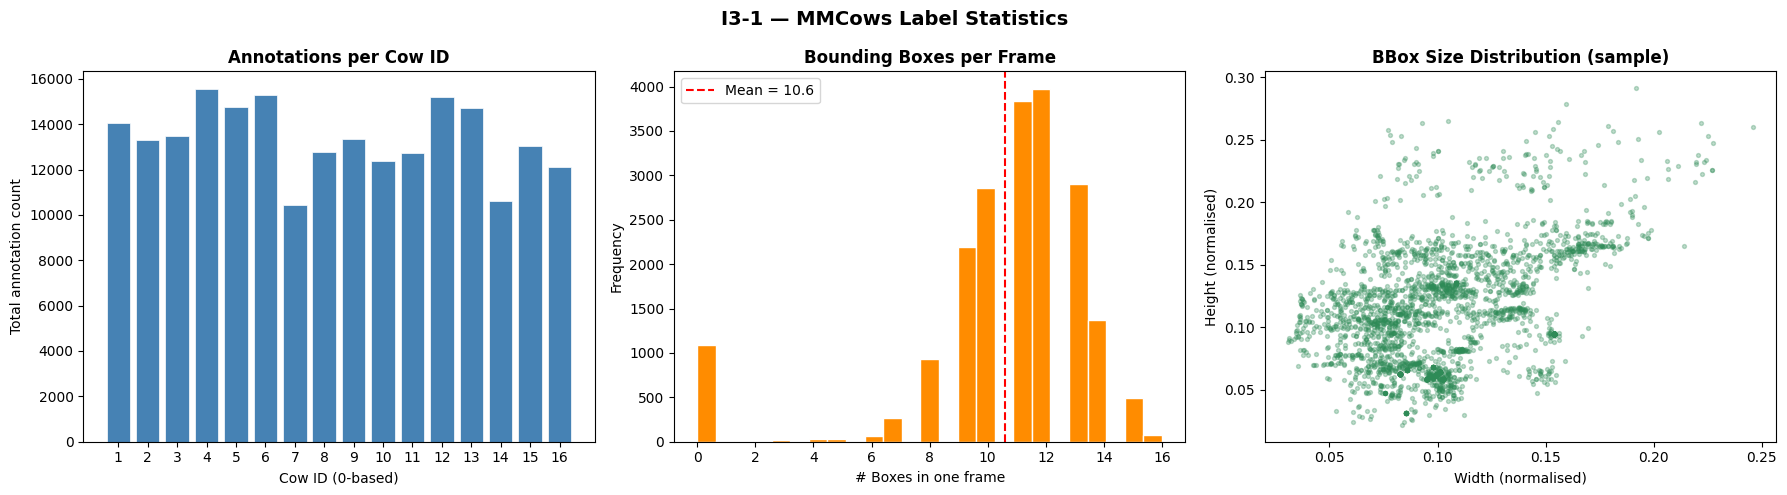

✅ Saved: outputs/results/i3_1_exploration/label_stats.png


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("I3-1 — MMCows Label Statistics", fontsize=14, fontweight="bold")

# Plot 1: Annotations per cow ID
ids    = sorted(cow_id_counts.keys())
counts = [cow_id_counts[i] for i in ids]
axes[0].bar(ids, counts, color="steelblue", edgecolor="white", linewidth=0.5)
axes[0].set_title("Annotations per Cow ID", fontweight="bold")
axes[0].set_xlabel("Cow ID (0-based)")
axes[0].set_ylabel("Total annotation count")
axes[0].set_xticks(ids)

# Plot 2: Boxes per frame
axes[1].hist(boxes_per_frame, bins=25, color="darkorange", edgecolor="white")
axes[1].set_title("Bounding Boxes per Frame", fontweight="bold")
axes[1].set_xlabel("# Boxes in one frame")
axes[1].set_ylabel("Frequency")
axes[1].axvline(np.mean(boxes_per_frame), color="red",
                linestyle="--", label=f"Mean = {np.mean(boxes_per_frame):.1f}")
axes[1].legend()

# Plot 3: BBox size scatter
axes[2].scatter(all_bw[:3000], all_bh[:3000],
                alpha=0.3, s=8, color="seagreen")
axes[2].set_title("BBox Size Distribution (sample)", fontweight="bold")
axes[2].set_xlabel("Width (normalised)")
axes[2].set_ylabel("Height (normalised)")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "label_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/results/i3_1_exploration/label_stats.png")


## Cell 8 — Visualise Annotations on a Real Image

We'll find a frame that has many cows visible and draw the bounding boxes on it.
This is our visual sanity check — if boxes align with the cows, labels are correct.


In [19]:
# Colour palette (one colour per cow ID)
PALETTE = [
    (255,  56,  56), (255, 157,  51), ( 54, 203,  68), ( 51, 153, 255),
    (255,  51, 153), (153, 255,  51), ( 51, 255, 255), (255, 255,  51),
    (153,  51, 255), (255, 153,  51), ( 51, 255, 153), (255,  51, 255),
    (200, 100,  50), ( 50, 200, 100), (100,  50, 200), (200, 200,  50),
    ( 50, 200, 200), (200,  50, 200), (150, 150, 150), ( 80, 200, 255),
]

def draw_boxes(image_rgb, annotations):
    """Draw bbox + cow ID label on a copy of the image."""
    vis = image_rgb.copy()
    vis_bgr = cv2.cvtColor(vis, cv2.COLOR_RGB2BGR)
    for a in annotations:
        color = PALETTE[a["cow_id"] % len(PALETTE)]
        cv2.rectangle(vis_bgr, (a["x1"], a["y1"]), (a["x2"], a["y2"]), color, 5)
        label   = f"Cow {a['cow_id']}"
        (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 1.5, 2)
        cv2.rectangle(vis_bgr,
                      (a["x1"], a["y1"] - th - 10),
                      (a["x1"] + tw + 6, a["y1"]),
                      color, -1)
        cv2.putText(vis_bgr, label, (a["x1"] + 3, a["y1"] - 5),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 0), 2, cv2.LINE_AA)
    return cv2.cvtColor(vis_bgr, cv2.COLOR_BGR2RGB)


# ── Find the richest frame (most boxes) ─────────────────────
best_img_path = None
best_anns     = []
best_count    = 0

img_root   = VISUAL_DATA_DIR / "images" / "0725"
label_root = VISUAL_DATA_DIR / "labels" / LABEL_SET

# Check label subfolder structure
label_subdirs = [d for d in label_root.iterdir() if d.is_dir()]
has_cam_subdirs = len(label_subdirs) > 0

for cam_dir in sorted(img_root.iterdir()):
    if not cam_dir.is_dir():
        continue
    for img_path in sorted(cam_dir.glob("*.jpg"))[:300]:   # check first 300 per cam
        stem = img_path.stem
        if has_cam_subdirs:
            lf = label_root / cam_dir.name / f"{stem}.txt"
        else:
            lf = label_root / f"{stem}.txt"
        if not lf.exists():
            continue
        anns = parse_label_file(lf)
        if len(anns) > best_count:
            best_count    = len(anns)
            best_img_path = img_path
            best_anns     = anns

print(f"Best frame    : {best_img_path}")
print(f"Annotations   : {best_count} cows")


Best frame    : C:\Users\DELL\Desktop\test\mmcows\data\raw\visual_data\images\0725\cam_1\1690274606_03-43-26.jpg
Annotations   : 14 cows


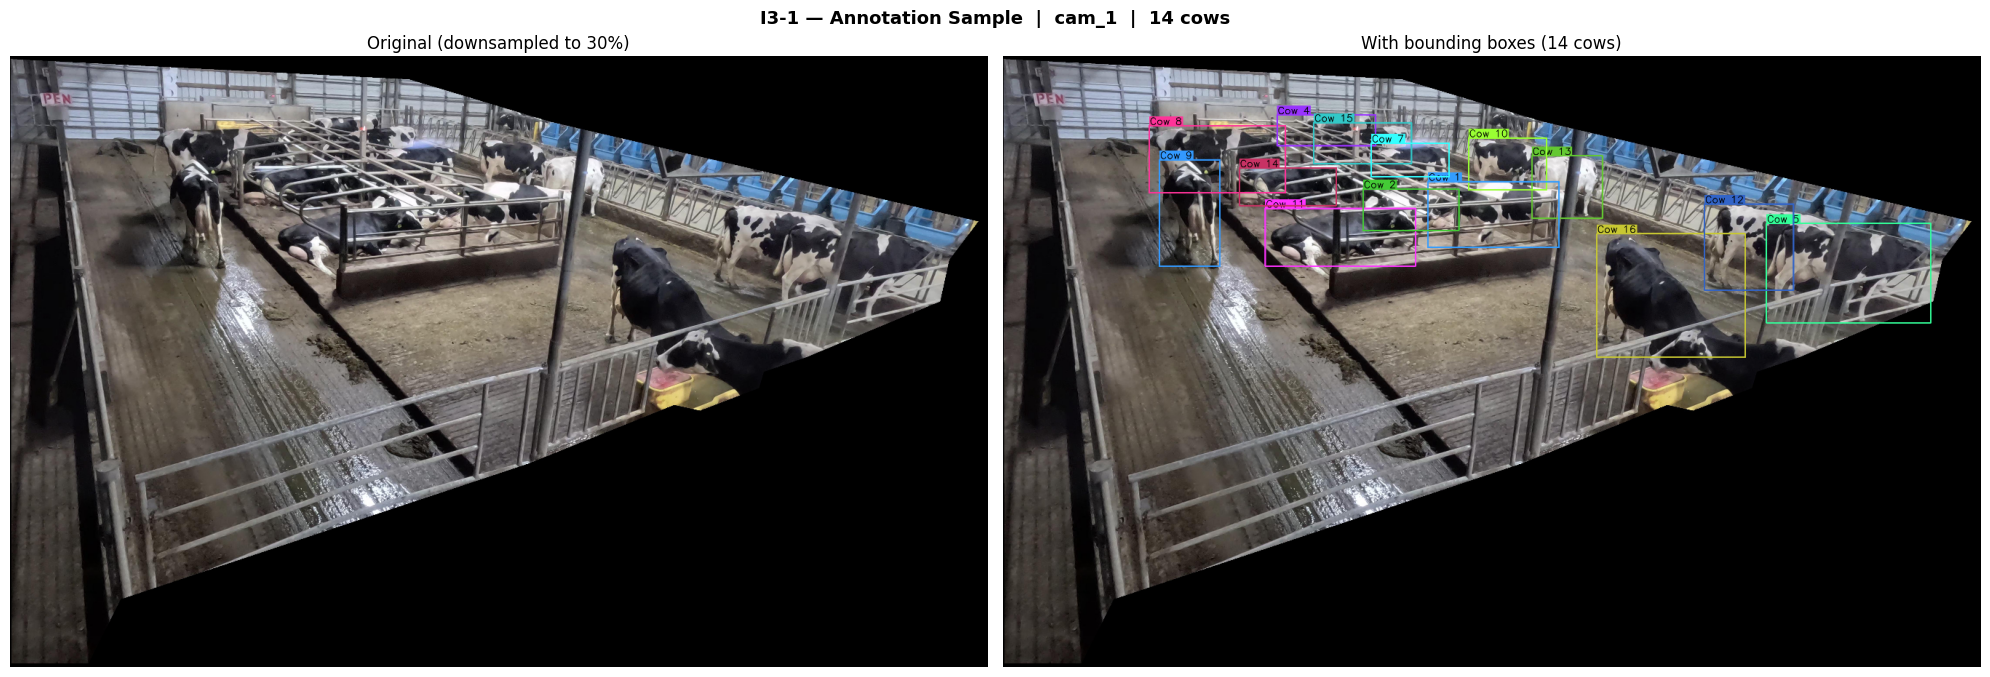

✅ Saved: outputs/results/i3_1_exploration/sample_annotation.png


In [20]:
# ── Load and display ────────────────────────────────────────
img_bgr  = cv2.imread(str(best_img_path))
img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_ann  = draw_boxes(img_rgb, best_anns)

# Downsample for display (originals are 4480×2800)
SCALE = 0.3
dw = int(IMG_W * SCALE)
dh = int(IMG_H * SCALE)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.suptitle(f"I3-1 — Annotation Sample  |  {best_img_path.parent.name}  |  {best_count} cows",
             fontsize=13, fontweight="bold")

axes[0].imshow(cv2.resize(img_rgb, (dw, dh)))
axes[0].set_title("Original (downsampled to 30%)")
axes[0].axis("off")

axes[1].imshow(cv2.resize(img_ann, (dw, dh)))
axes[1].set_title(f"With bounding boxes ({best_count} cows)")
axes[1].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "sample_annotation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: outputs/results/i3_1_exploration/sample_annotation.png")


## Cell 9 — Same Timestamp Across All 4 Cameras

MMCows uses 4 isometric cameras filming the same pen.  
Let's pick one timestamp and show all 4 camera views side by side.  
This is important for I3-5 (triangulation) — we need to understand how the cameras overlap.


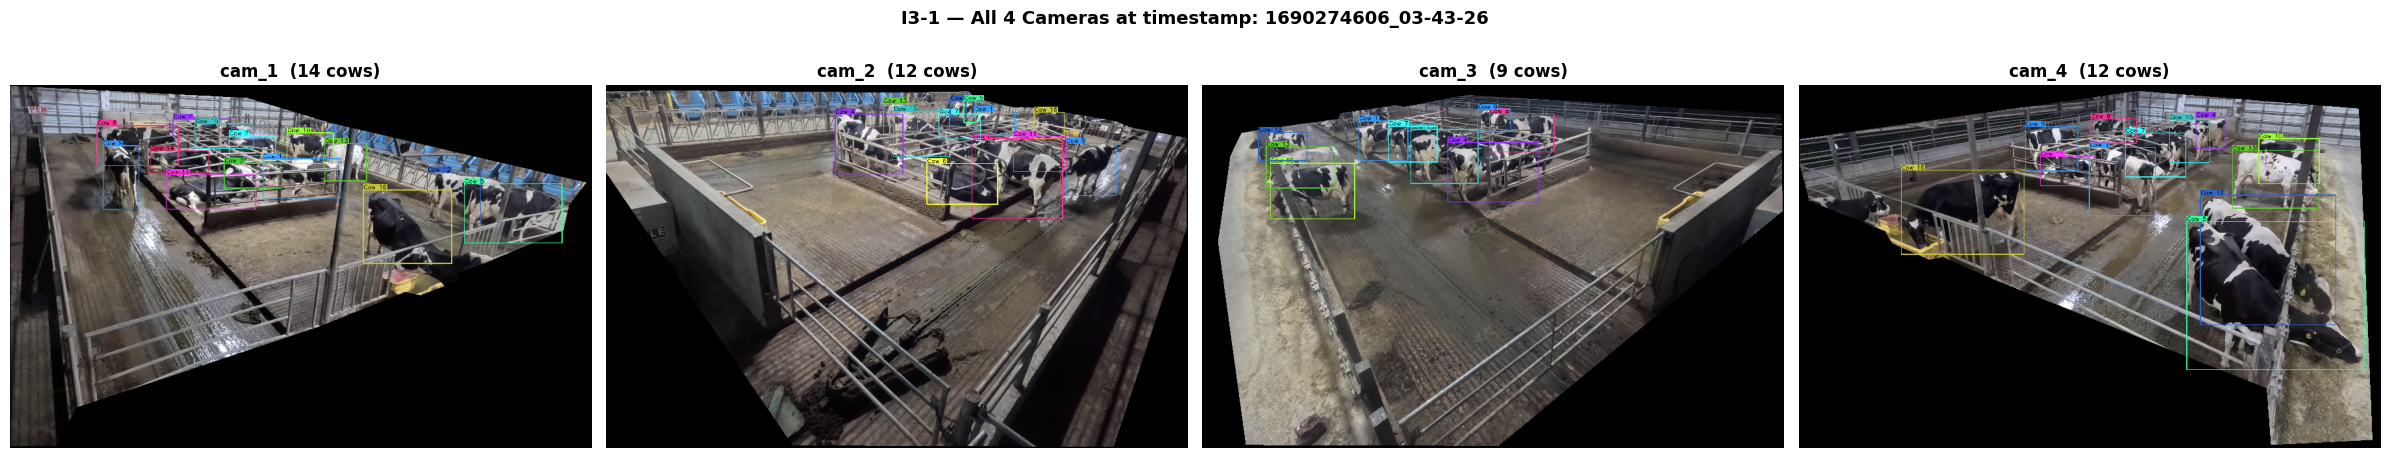

✅ Saved: outputs/results/i3_1_exploration/four_cameras.png


In [22]:
# Pick the filename from the best frame found above
target_stem = best_img_path.stem   # e.g. "1658765400"

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle(f"I3-1 — All 4 Cameras at timestamp: {target_stem}",
             fontsize=13, fontweight="bold")

found_any = False
for i, cam in enumerate(["cam_1", "cam_2", "cam_3", "cam_4"]):
    cam_dir   = VISUAL_DATA_DIR / "images" / "0725" / cam
    img_path  = cam_dir / f"{target_stem}.jpg"

    if not img_path.exists():
        # Try .png
        img_path = cam_dir / f"{target_stem}.png"

    if img_path.exists():
        img   = cv2.imread(str(img_path))
        img   = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Also draw boxes if label exists
        if has_cam_subdirs:
            lf = label_root / cam / f"{target_stem}.txt"
        else:
            lf = label_root / f"{target_stem}.txt"
        if lf.exists():
            anns = parse_label_file(lf)
            img  = draw_boxes(img, anns)
            n_cows = len(anns)
        else:
            n_cows = 0

        axes[i].imshow(cv2.resize(img, (int(IMG_W*0.2), int(IMG_H*0.2))))
        axes[i].set_title(f"{cam}  ({n_cows} cows)", fontweight="bold")
        found_any = True
    else:
        axes[i].text(0.5, 0.5, f"{cam}\nnot found",
                     ha="center", va="center", transform=axes[i].transAxes)

    axes[i].axis("off")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "four_cameras.png", dpi=120, bbox_inches="tight")
plt.show()

if found_any:
    print("✅ Saved: outputs/results/i3_1_exploration/four_cameras.png")
else:
    print("⚠️  No matching images found across cameras for this timestamp.")
    print("   The timestamp naming might differ between cameras — check Cell 3 output.")


## Cell 10 — Projection Matrices

Each camera has a **3×4 projection matrix** stored in `proj_mat/`.  
This matrix maps a **3D world point** `[X, Y, Z, 1]` → **2D pixel** `[u, v, 1]`.

We'll need these in **I3-5** for the AdaGrad triangulation step.
For now, let's just load them and check their shapes.


In [25]:
proj_dir = VISUAL_DATA_DIR / "proj_mat" / "0725"

print("Files in proj_mat/:")
all_mat_files = sorted(proj_dir.rglob("*"))
for f in all_mat_files[:15]:
    print(f"  {f.relative_to(VISUAL_DATA_DIR)}")
if len(all_mat_files) > 15:
    print(f"  ... ({len(all_mat_files) - 15} more)")


Files in proj_mat/:
  proj_mat\0725\proj_mat_cam1.xml
  proj_mat\0725\proj_mat_cam2.xml
  proj_mat\0725\proj_mat_cam3.xml
  proj_mat\0725\proj_mat_cam4.xml


In [28]:
# Try to load the projection matrices
mat_files = [f for f in sorted(proj_dir.rglob("*"))
             if f.suffix in (".txt", ".npy", ".csv", ".xml")]

proj_matrices = {}

for mf in mat_files:
    try:
        if mf.suffix == ".npy":
            mat = np.load(str(mf))
        else:
            mat = np.loadtxt(str(mf))
        proj_matrices[mf.name] = mat
        print(f"  ✅ {mf.name}  →  shape: {mat.shape}")
        print(f"     {mat}")
        print()
    except Exception as e:
        print(f"  ⚠️  {mf.name}  →  could not load: {e}")

if not proj_matrices:
    print("No matrix files found yet.")
    print("They may be in a different format — share what you see in Cell 10a above.")


  ⚠️  proj_mat_cam1.xml  →  could not load: could not convert string '<?xml' to float64 at row 0, column 1.
  ⚠️  proj_mat_cam2.xml  →  could not load: could not convert string '<?xml' to float64 at row 0, column 1.
  ⚠️  proj_mat_cam3.xml  →  could not load: could not convert string '<?xml' to float64 at row 0, column 1.
  ⚠️  proj_mat_cam4.xml  →  could not load: could not convert string '<?xml' to float64 at row 0, column 1.
No matrix files found yet.
They may be in a different format — share what you see in Cell 10a above.


## Cell 11 — Behaviour Labels (Preview)

The `behavior_labels/individual/` folder contains manually annotated behaviour  
labels at **1-second resolution** for the full annotated day (7/25).

These will be used in **Increment 4** (behaviour classification).  
For now, let's just peek at the format.


In [29]:
beh_dir = VISUAL_DATA_DIR / "behavior_labels" / "individual"

if beh_dir.exists():
    files = sorted(beh_dir.glob("*"))
    print(f"Files in behavior_labels/individual/: {len(files)}")
    for f in files[:10]:
        print(f"  {f.name}")

    # Load the first one
    if files:
        sample = files[0]
        print(f"\nSample file: {sample.name}")
        with open(sample) as f:
            lines = f.readlines()
        print(f"Lines: {len(lines)}")
        print("First 10 lines:")
        for line in lines[:10]:
            print(f"  {line.rstrip()}")
else:
    print("⚠️  behavior_labels/individual/ not found.")


Files in behavior_labels/individual/: 16
  C01_0725.csv
  C02_0725.csv
  C03_0725.csv
  C04_0725.csv
  C05_0725.csv
  C06_0725.csv
  C07_0725.csv
  C08_0725.csv
  C09_0725.csv
  C10_0725.csv

Sample file: C01_0725.csv
Lines: 86401
First 10 lines:
  timestamp,datetime,behavior
  1690261200,0:00:00,0
  1690261201,0:00:01,0
  1690261202,0:00:02,0
  1690261203,0:00:03,0
  1690261204,0:00:04,0
  1690261205,0:00:05,0
  1690261206,0:00:06,0
  1690261207,0:00:07,0
  1690261208,0:00:08,0


## Cell 12 — I3-1 Summary & Approval Checklist

In [30]:
print("=" * 60)
print("  I3-1 EXPLORATION SUMMARY")
print("=" * 60)
print()
print(f"  Dataset root    : {VISUAL_DATA_DIR.resolve()}")
print(f"  Total images    : {sum(len(v) for v in cam_image_counts.values()):,}")
print(f"  Total labels    : {len(label_files):,}  ({LABEL_SET})")
print(f"  Total annots    : {len(all_anns):,}")
print(f"  Unique cow IDs  : {sorted(cow_id_counts.keys())}")
print(f"  Avg boxes/frame : {np.mean(boxes_per_frame):.1f}")
print(f"  Outputs saved to: {OUTPUT_DIR.resolve()}")
print()
print("─" * 60)
print("  APPROVAL CHECKLIST — confirm before moving to I3-2:")
print("─" * 60)
checklist = [
    "Folder structure verified",
    "Images are 4480×2800 across all 4 cameras",
    "Labels are in YOLO format: [cow_id, xc, yc, w, h]",
    "Bounding boxes visually align with cows in sample image",
    "All 4 camera views visible for same timestamp",
    "Projection matrices found and loadable",
    "Behaviour labels format understood",
]
for item in checklist:
    print(f"  ☐  {item}")
print()
print("  ✅ Share this notebook output for approval → then I3-2.")
print("=" * 60)


  I3-1 EXPLORATION SUMMARY

  Dataset root    : C:\Users\DELL\Desktop\test\mmcows\data\raw\visual_data
  Total images    : 20,153
  Total labels    : 20,153  (combined/0725)
  Total annots    : 213,705
  Unique cow IDs  : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]
  Avg boxes/frame : 10.6
  Outputs saved to: C:\Users\DELL\Desktop\test\mmcows\outputs\results\i3_1_exploration

────────────────────────────────────────────────────────────
  APPROVAL CHECKLIST — confirm before moving to I3-2:
────────────────────────────────────────────────────────────
  ☐  Folder structure verified
  ☐  Images are 4480×2800 across all 4 cameras
  ☐  Labels are in YOLO format: [cow_id, xc, yc, w, h]
  ☐  Bounding boxes visually align with cows in sample image
  ☐  All 4 camera views visible for same timestamp
  ☐  Projection matrices found and loadable
  ☐  Behaviour labels format understood

  ✅ Share this notebook output for approval → then I3-2.
